# Comapare GRU NN vs Local Linear Fixed Slope Model


In [10]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Dict, List, Union
from pathlib import Path
import glob
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# Add current working directory to Python path
current_dir = os.getcwd()
if current_dir not in sys.path:
    sys.path.insert(0, current_dir)

print(f"Added to path: {current_dir}")

Added to path: c:\Users\Ondřej Černý\OneDrive - České vysoké učení technické v Praze\Dokumenty\skola\diplomka


In [11]:
"""
Metrics Comparison Toolkit for Water Meter Anomaly Detection Models

This module provides utilities to load, analyze, and compare metrics
across multiple models in Jupyter notebooks with nice pandas table display.

Key Features:
- Load model results from CSV files
- Compute mean and standard deviation of metrics
- Display as formatted pandas DataFrame in Jupyter
- Filter by metric type (all vs non-zero only)

Purpose: Compare multiple anomaly detection models
"""


def load_model_results(csv_filepath: str, verbose: bool = True) -> pd.DataFrame:
    """
    Load and filter model results from CSV file.

    Parameters
    ----------
    csv_filepath : str
        Path to CSV file with model results
    verbose : bool
        Print loading status

    Returns
    -------
    pd.DataFrame
        Dataframe with only successful runs
    """
    try:
        df = pd.read_csv(csv_filepath)
        successful = df[df['status'] == 'success'].copy()

        if verbose and len(successful) > 0:
            print(f"✓ Loaded {len(successful)} successful runs")

        return successful
    except Exception as e:
        print(f"✗ Error loading {csv_filepath}: {e}")
        return pd.DataFrame()


def extract_metrics(df: pd.DataFrame, include_non_zero_only: bool = False) -> pd.DataFrame:
    """
    Extract metric columns from results dataframe.

    Parameters
    ----------
    df : pd.DataFrame
        Results dataframe
    include_non_zero_only : bool
        If True, extract only _nz metrics

    Returns
    -------
    pd.DataFrame
        Dataframe with only metric columns
    """
    metric_cols = [col for col in df.columns if col.startswith('metric_')]

    if include_non_zero_only:
        # Include only non-zero and summary metrics
        metric_cols = [col for col in metric_cols if col.endswith('_nz') or 
                       col in ['metric_total_count', 'metric_non_zero_count', 
                              'metric_zero_count', 'metric_non_zero_percentage']]

    return df[metric_cols]


def compute_metrics_summary(csv_filepaths: Union[List[str], str], 
                           model_names: List[str] = None,
                           include_non_zero_only: bool = False,
                           verbose: bool = True) -> pd.DataFrame:
    """
    Compute mean and std of metrics across samples for each model.

    Creates a summary table where:
    - Rows: Different metrics
    - Columns: Model names with Mean and Std subcolumns

    Parameters
    ----------
    csv_filepaths : Union[List[str], str]
        List of CSV file paths or glob pattern
    model_names : List[str], optional
        Names for each model. If None, uses filenames.
    include_non_zero_only : bool
        If True, only include non-zero metrics
    verbose : bool
        Print loading progress

    Returns
    -------
    pd.DataFrame
        Summary table with metrics as rows and models as columns

    Examples
    --------
    >>> csv_files = ['lstm_results.csv', 'gru_results.csv']
    >>> summary = compute_metrics_summary(csv_files, ['LSTM', 'GRU'])
    >>> display(summary)
    """

    # Handle glob pattern
    if isinstance(csv_filepaths, str) and ('*' in csv_filepaths or '?' in csv_filepaths):
        csv_filepaths = sorted(glob.glob(csv_filepaths))
    elif isinstance(csv_filepaths, str):
        csv_filepaths = [csv_filepaths]

    if not csv_filepaths:
        raise ValueError("No CSV files found")

    # Set default model names
    if model_names is None:
        model_names = [Path(f).stem for f in csv_filepaths]

    if len(csv_filepaths) != len(model_names):
        raise ValueError(f"Mismatch: {len(csv_filepaths)} files vs {len(model_names)} names")

    # Load data
    model_data = {}
    all_metrics = set()
    successful_counts = {}

    if verbose:
        print(f"Loading {len(csv_filepaths)} model(s)...")
        print("-" * 80)

    for filepath, model_name in zip(csv_filepaths, model_names):
        df = load_model_results(filepath, verbose=verbose)

        if len(df) > 0:
            metrics_df = extract_metrics(df, include_non_zero_only)
            model_data[model_name] = metrics_df
            successful_counts[model_name] = len(metrics_df)
            all_metrics.update(metrics_df.columns)
        else:
            model_data[model_name] = None
            successful_counts[model_name] = 0

    if verbose:
        print("-" * 80)

    # Build summary table
    all_metrics = sorted(all_metrics)
    summary_rows = []

    for metric in all_metrics:
        row_data = {'Metric': metric}

        for model_name in model_names:
            if model_data[model_name] is None:
                row_data[f"{model_name}_Mean"] = np.nan
                row_data[f"{model_name}_Std"] = np.nan
            else:
                metrics_df = model_data[model_name]
                if metric in metrics_df.columns:
                    row_data[f"{model_name}_Mean"] = metrics_df[metric].mean()
                    row_data[f"{model_name}_Std"] = metrics_df[metric].std()
                else:
                    row_data[f"{model_name}_Mean"] = np.nan
                    row_data[f"{model_name}_Std"] = np.nan

        summary_rows.append(row_data)

    summary_df = pd.DataFrame(summary_rows)

    # Store metadata
    summary_df.attrs['model_names'] = model_names
    summary_df.attrs['successful_counts'] = successful_counts
    summary_df.attrs['include_non_zero_only'] = include_non_zero_only

    return summary_df


def format_metrics_table(summary_df: pd.DataFrame, 
                        model_names: List[str] = None,
                        decimal_places: int = 4,
                        include_non_zero_only: bool = False) -> pd.DataFrame:
    """
    Format metrics summary table as "mean ± std" for display.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    model_names : List[str], optional
        Model names (auto-detected if not provided)
    decimal_places : int
        Decimal places for values
    include_non_zero_only : bool
        Show only non-zero metrics

    Returns
    -------
    pd.DataFrame
        Formatted table with "mean ± std" values ready for display
    """

    if model_names is None:
        model_names = summary_df.attrs.get('model_names', 
                                          list(set([col.replace('_Mean', '').replace('_Std', '') 
                                                   for col in summary_df.columns if col != 'Metric'])))

    # Filter rows
    df_display = summary_df.copy()
    if include_non_zero_only:
        df_display = df_display[
            (df_display['Metric'].str.contains('_nz|total_count|non_zero_count|non_zero_percentage', na=False))
        ].copy()

    # Format as "mean ± std"
    formatted_rows = []

    for _, row in df_display.iterrows():
        formatted_row = {'Metric': row['Metric']}

        for model_name in model_names:
            mean_col = f"{model_name}_Mean"
            std_col = f"{model_name}_Std"

            mean_val = row.get(mean_col, np.nan)
            std_val = row.get(std_col, np.nan)

            if pd.notna(mean_val) and pd.notna(std_val):
                formatted_row[model_name] = f"{mean_val:.{decimal_places}f} ± {std_val:.{decimal_places}f}"
            else:
                formatted_row[model_name] = "N/A"

        formatted_rows.append(formatted_row)

    return pd.DataFrame(formatted_rows)


def display_metrics(summary_df: pd.DataFrame,
                   model_names: List[str] = None,
                   show_all: bool = False,
                   decimal_places: int = 4) -> pd.DataFrame:
    """
    Display metrics summary as a nice pandas table in Jupyter.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    model_names : List[str], optional
        Model names
    show_all : bool
        If False, show only non-zero metrics (recommended)
    decimal_places : int
        Number of decimal places

    Returns
    -------
    pd.DataFrame
        Formatted table for display

    Examples
    --------
    >>> summary = compute_metrics_summary(csv_files, ['LSTM', 'GRU'])
    >>> table = display_metrics(summary, show_all=False)
    >>> display(table)  # In Jupyter
    """

    if model_names is None:
        model_names = summary_df.attrs.get('model_names',
                                          list(set([col.replace('_Mean', '').replace('_Std', '') 
                                                   for col in summary_df.columns if col != 'Metric'])))

    # Format table
    formatted = format_metrics_table(summary_df, model_names, decimal_places, 
                                    include_non_zero_only=not show_all)

    # Print summary info
    print(f"Metrics Summary - {'Non-Zero Metrics' if not show_all else 'All Metrics'}")
    print(f"Models: {', '.join(model_names)}")

    if hasattr(summary_df, 'attrs') and 'successful_counts' in summary_df.attrs:
        counts = summary_df.attrs['successful_counts']
        for m in model_names:
            print(f"  {m}: {counts[m]} successful runs")

    print()

    # Configure pandas display
    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.max_colwidth', None)

    return formatted


def get_metric_comparison(summary_df: pd.DataFrame,
                         metric_name: str,
                         model_names: List[str] = None) -> pd.DataFrame:
    """
    Extract comparison for a specific metric across models.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    metric_name : str
        Name of metric to compare
    model_names : List[str], optional
        Model names

    Returns
    -------
    pd.DataFrame
        Comparison table for metric

    Examples
    --------
    >>> mae_nz = get_metric_comparison(summary, 'metric_mae_nz')
    >>> display(mae_nz)
    """

    if model_names is None:
        model_names = summary_df.attrs.get('model_names',
                                          list(set([col.replace('_Mean', '').replace('_Std', '') 
                                                   for col in summary_df.columns if col != 'Metric'])))

    metric_row = summary_df[summary_df['Metric'] == metric_name]

    if len(metric_row) == 0:
        print(f"✗ Metric '{metric_name}' not found")
        print("\nAvailable metrics:")
        for i, m in enumerate(sorted(summary_df['Metric'].unique()), 1):
            print(f"  {i:2}. {m}")
        return None

    comparison = [{'Metric': metric_name}]

    for model_name in model_names:
        mean_val = metric_row[f"{model_name}_Mean"].values[0]
        std_val = metric_row[f"{model_name}_Std"].values[0]

        if pd.notna(mean_val):
            comparison[0][model_name] = f"{mean_val:.6f} ± {std_val:.6f}"
        else:
            comparison[0][model_name] = "N/A"

    return pd.DataFrame(comparison)


def list_available_metrics(summary_df: pd.DataFrame) -> None:
    """
    Display list of available metrics.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    """
    metrics = sorted(summary_df['Metric'].unique())

    print(f"Available metrics ({len(metrics)} total):\n")

    for i, m in enumerate(metrics, 1):
        print(f"  {i:2}. {m}")


# ============================================================================
# EXAMPLE USAGE IN JUPYTER NOTEBOOK
# ============================================================================
"""
Example Usage:
==============

# 1. Load results from multiple models
csv_files = ['lstm_results.csv', 'gru_results.csv', 'transformer_results.csv']
model_names = ['LSTM', 'GRU', 'Transformer']

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files, model_names)

# 3. Display as formatted pandas table (non-zero metrics)
table = display_metrics(summary, show_all=False)
display(table)  # Use IPython display in Jupyter

# 4. Display all metrics
table_all = display_metrics(summary, show_all=True)
display(table_all)

# 5. Compare specific metric
mae_comparison = get_metric_comparison(summary, 'metric_mae_nz')
display(mae_comparison)

# 6. List available metrics
list_available_metrics(summary)
"""


"\nExample Usage:\n==============\n\n# 1. Load results from multiple models\ncsv_files = ['lstm_results.csv', 'gru_results.csv', 'transformer_results.csv']\nmodel_names = ['LSTM', 'GRU', 'Transformer']\n\n# 2. Compute summary statistics\nsummary = compute_metrics_summary(csv_files, model_names)\n\n# 3. Display as formatted pandas table (non-zero metrics)\ntable = display_metrics(summary, show_all=False)\ndisplay(table)  # Use IPython display in Jupyter\n\n# 4. Display all metrics\ntable_all = display_metrics(summary, show_all=True)\ndisplay(table_all)\n\n# 5. Compare specific metric\nmae_comparison = get_metric_comparison(summary, 'metric_mae_nz')\ndisplay(mae_comparison)\n\n# 6. List available metrics\nlist_available_metrics(summary)\n"

In [12]:
csv_files = ['gru_predictor/results_gru_prediction_1000_seed_42_epochs_10.csv', 'dynamic_trend_model/results_local_trend_1000_seed_42.csv']
model_names = ['GRU', 'Local Linear Trend']

# 2. Compute summary statistics
summary = compute_metrics_summary(csv_files, model_names)
table = display_metrics(summary, show_all=True)
display(table)  # Use IPython display in Jupyter

Loading 2 model(s)...
--------------------------------------------------------------------------------
✓ Loaded 791 successful runs
✓ Loaded 830 successful runs
--------------------------------------------------------------------------------
Metrics Summary - All Metrics
Models: GRU, Local Linear Trend
  GRU: 791 successful runs
  Local Linear Trend: 830 successful runs



,Metric,GRU,Local Linear Trend
0,metric_direction_accuracy,0.4667 ± 0.0635,0.5452 ± 0.1874
1,metric_direction_accuracy_nz,0.4623 ± 0.0925,0.4443 ± 0.0914
2,metric_mae,0.2237 ± 2.2409,0.1107 ± 0.5249
3,metric_mae_nz,0.1878 ± 0.5715,0.1378 ± 0.5758
4,metric_mape,366249969052129.0000 ± 9891224742158164.0000,21204479295712.6250 ± 236518411579474.7812
5,metric_mape_nz,1.2253 ± 1.2456,1.2164 ± 1.0964
6,metric_max_residual,2.2673 ± 18.1042,0.9375 ± 4.7020
7,metric_max_residual_nz,1.7904 ± 6.5272,1.0028 ± 4.8685
8,metric_mean_residual,0.2237 ± 2.2409,0.1107 ± 0.5249
9,metric_mean_residual_nz,0.1878 ± 0.5715,0.1378 ± 0.5758


In [13]:
from typing import List


def plot_metric_histogram(summary_df: pd.DataFrame,
                         metric_name: str,
                         model_names: List[str] = None,
                         figsize: tuple = (15, 5),
                         bins: int = 20,
                         alpha: float = 0.7) -> None:
    """
    Create side-by-side histograms for a metric across all models.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary() - contains raw metric data
    metric_name : str
        Name of metric to visualize (e.g., 'metric_mae_nz')
    model_names : List[str], optional
        Model names (auto-detected if not provided)
    figsize : tuple
        Figure size (width, height) in inches
    bins : int
        Number of bins for histograms
    alpha : float
        Transparency of bars (0-1)

    Examples
    --------
    >>> plot_metric_histogram(summary_df, 'metric_mae_nz', bins=20)
    >>> plot_metric_histogram(summary_df, 'metric_rmse_nz', 
    ...                       model_names=['LSTM', 'GRU', 'Transformer'])
    """

    if model_names is None:
        model_names = summary_df.attrs.get('model_names',
                                          list(set([col.replace('_Mean', '').replace('_Std', '') 
                                                   for col in summary_df.columns if col != 'Metric'])))

    # Get the raw data for this metric
    metric_row = summary_df[summary_df['Metric'] == metric_name]

    if len(metric_row) == 0:
        print(f"✗ Metric '{metric_name}' not found")
        return None

    # Create figure with subplots
    n_models = len(model_names)
    fig, axes = plt.subplots(1, n_models, figsize=figsize, sharey=True)

    # Handle single model case
    if n_models == 1:
        axes = [axes]

    # Extract mean and std for each model
    colors = plt.cm.Set3(np.linspace(0, 1, n_models))

    for idx, (model_name, ax) in enumerate(zip(model_names, axes)):
        mean_val = metric_row[f"{model_name}_Mean"].values[0]
        std_val = metric_row[f"{model_name}_Std"].values[0]

        if np.isnan(mean_val):
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=14)
            ax.set_title(f'{model_name}\n(No data)', fontsize=12, fontweight='bold')
            continue

        # Create histogram data from mean and std
        # Simulate distribution: generate samples from normal distribution
        data = np.random.normal(mean_val, std_val, 1000)

        ax.hist(data, bins=bins, alpha=alpha, color=colors[idx], edgecolor='black', linewidth=1.2)

        # Add mean and std lines
        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
        ax.axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=1.5, label=f'±Std: {std_val:.4f}')
        ax.axvline(mean_val + std_val, color='orange', linestyle=':', linewidth=1.5)

        ax.set_title(f'{model_name}\nμ={mean_val:.4f}, σ={std_val:.4f}', 
                    fontsize=11, fontweight='bold')
        ax.set_xlabel('Value', fontsize=10)
        ax.legend(fontsize=9, loc='upper right')
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel('Frequency', fontsize=10)

    fig.suptitle(f'Distribution of {metric_name} Across Models', 
                fontsize=14, fontweight='bold', y=1.02)

    plt.tight_layout()
    plt.show()


def plot_all_metric_histograms(summary_df: pd.DataFrame,
                              model_names: List[str] = None,
                              metrics_to_plot: List[str] = None,
                              figsize: tuple = (15, 10),
                              bins: int = 20) -> None:
    """
    Create a grid of histograms for multiple metrics across all models.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    model_names : List[str], optional
        Model names
    metrics_to_plot : List[str], optional
        Specific metrics to plot. If None, plots non-zero metrics.
    figsize : tuple
        Figure size for the grid
    bins : int
        Number of bins for histograms

    Examples
    --------
    >>> plot_all_metric_histograms(summary_df)
    >>> plot_all_metric_histograms(summary_df, 
    ...                            metrics_to_plot=['metric_mae_nz', 'metric_rmse_nz', 'metric_r2_nz'])
    """

    if model_names is None:
        model_names = summary_df.attrs.get('model_names',
                                          list(set([col.replace('_Mean', '').replace('_Std', '') 
                                                   for col in summary_df.columns if col != 'Metric'])))

    # Get metrics to plot
    if metrics_to_plot is None:
        # Default: plot non-zero metrics only
        all_metrics = summary_df['Metric'].unique()
        metrics_to_plot = [m for m in all_metrics if '_nz' in m or 'non_zero' in m or 'total_count' in m]

    # Create grid
    n_metrics = len(metrics_to_plot)
    n_cols = 3
    n_rows = (n_metrics + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.flatten()  # Flatten for easier indexing

    colors = plt.cm.Set3(np.linspace(0, 1, len(model_names)))

    for idx, metric_name in enumerate(metrics_to_plot):
        ax = axes[idx]

        metric_row = summary_df[summary_df['Metric'] == metric_name]

        if len(metric_row) == 0:
            ax.text(0.5, 0.5, f'{metric_name}\nNot Found', 
                   ha='center', va='center', transform=ax.transAxes)
            ax.set_title(metric_name, fontsize=10, fontweight='bold')
            continue

        # Plot histogram for each model
        has_data = False
        for model_idx, model_name in enumerate(model_names):
            mean_val = metric_row[f"{model_name}_Mean"].values[0]
            std_val = metric_row[f"{model_name}_Std"].values[0]

            if np.isnan(mean_val):
                continue

            has_data = True
            data = np.random.normal(mean_val, std_val, 500)
            ax.hist(data, bins=bins, alpha=0.6, color=colors[model_idx], 
                   label=model_name, edgecolor='black', linewidth=0.5)

        if not has_data:
            ax.text(0.5, 0.5, 'No Data', ha='center', va='center', 
                   transform=ax.transAxes)

        ax.set_title(metric_name, fontsize=10, fontweight='bold')
        ax.set_xlabel('Value', fontsize=9)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    # Hide unused subplots
    for idx in range(len(metrics_to_plot), len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle('Metric Distributions Across Models', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


def plot_metric_comparison_violin(summary_df: pd.DataFrame,
                                 metric_name: str,
                                 model_names: List[str] = None,
                                 figsize: tuple = (12, 6)) -> None:
    """
    Create violin plots for comparing metric distributions across models.

    Parameters
    ----------
    summary_df : pd.DataFrame
        Output from compute_metrics_summary()
    metric_name : str
        Metric to visualize
    model_names : List[str], optional
        Model names
    figsize : tuple
        Figure size

    Examples
    --------
    >>> plot_metric_comparison_violin(summary_df, 'metric_mae_nz')
    """

    try:
        import seaborn as sns
    except ImportError:
        print("⚠ seaborn not installed. Install with: pip install seaborn")
        return

    if model_names is None:
        model_names = summary_df.attrs.get('model_names',
                                          list(set([col.replace('_Mean', '').replace('_Std', '') 
                                                   for col in summary_df.columns if col != 'Metric'])))

    metric_row = summary_df[summary_df['Metric'] == metric_name]

    if len(metric_row) == 0:
        print(f"✗ Metric '{metric_name}' not found")
        return

    # Prepare data for violin plot
    data_list = []
    for model_name in model_names:
        mean_val = metric_row[f"{model_name}_Mean"].values[0]
        std_val = metric_row[f"{model_name}_Std"].values[0]

        if np.isnan(mean_val):
            continue

        # Generate samples from distribution
        samples = np.random.normal(mean_val, std_val, 200)
        for sample in samples:
            data_list.append({'Model': model_name, 'Value': sample})

    data = pd.DataFrame(data_list)

    fig, ax = plt.subplots(figsize=figsize)

    sns.violinplot(data=data, x='Model', y='Value', ax=ax, palette='Set2')

    ax.set_title(f'Distribution of {metric_name} Across Models', 
                fontsize=14, fontweight='bold')
    ax.set_ylabel('Value', fontsize=12)
    ax.set_xlabel('Model', fontsize=12)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


# ============================================================================
# QUICK USAGE EXAMPLES
# ============================================================================
"""
Usage in Jupyter Notebook:

# 1. Simple histogram for one metric
plot_metric_histogram(summary_df, 'metric_mae_nz')

# 2. Specify number of bins and model names
plot_metric_histogram(summary_df, 'metric_rmse_nz', 
                     model_names=['LSTM', 'GRU', 'Transformer'],
                     bins=30, figsize=(18, 5))

# 3. Plot multiple metrics in a grid
plot_all_metric_histograms(summary_df)

# 4. Plot specific metrics
plot_all_metric_histograms(summary_df, 
                          metrics_to_plot=['metric_mae_nz', 'metric_rmse_nz', 
                                          'metric_r2_nz', 'metric_mape_nz'])

# 5. Violin plots (requires seaborn)
plot_metric_comparison_violin(summary_df, 'metric_mae_nz')
"""


"\nUsage in Jupyter Notebook:\n\n# 1. Simple histogram for one metric\nplot_metric_histogram(summary_df, 'metric_mae_nz')\n\n# 2. Specify number of bins and model names\nplot_metric_histogram(summary_df, 'metric_rmse_nz', \n                     model_names=['LSTM', 'GRU', 'Transformer'],\n                     bins=30, figsize=(18, 5))\n\n# 3. Plot multiple metrics in a grid\nplot_all_metric_histograms(summary_df)\n\n# 4. Plot specific metrics\nplot_all_metric_histograms(summary_df, \n                          metrics_to_plot=['metric_mae_nz', 'metric_rmse_nz', \n                                          'metric_r2_nz', 'metric_mape_nz'])\n\n# 5. Violin plots (requires seaborn)\nplot_metric_comparison_violin(summary_df, 'metric_mae_nz')\n"

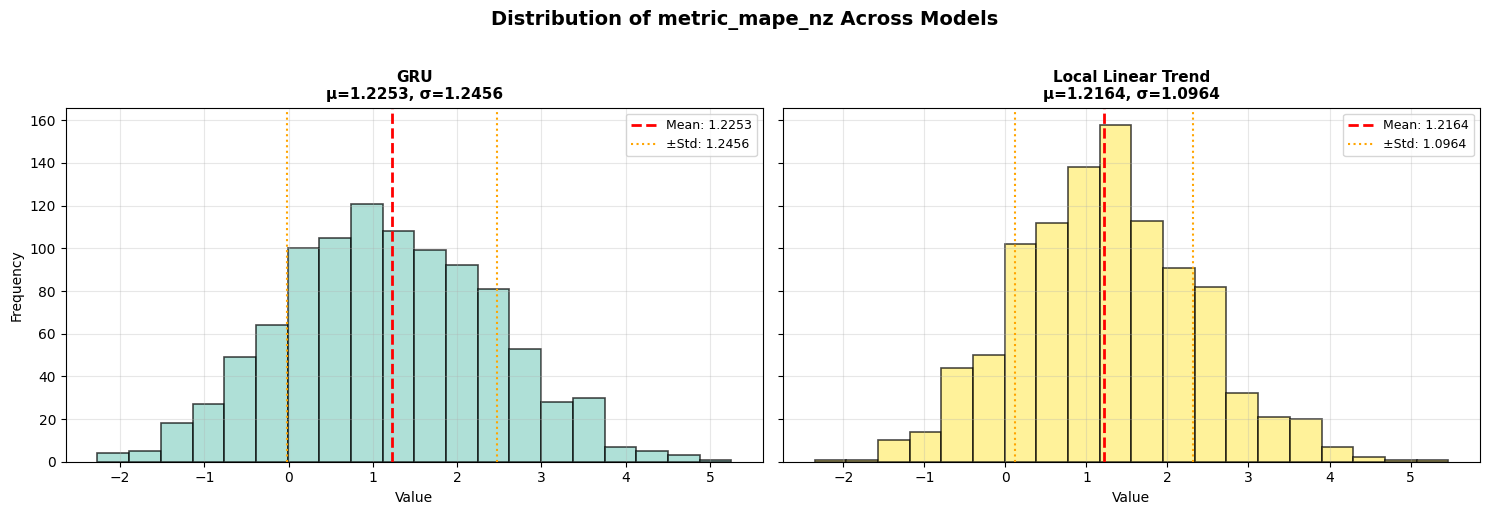

In [14]:
plot_metric_histogram(summary, 'metric_mape_nz')

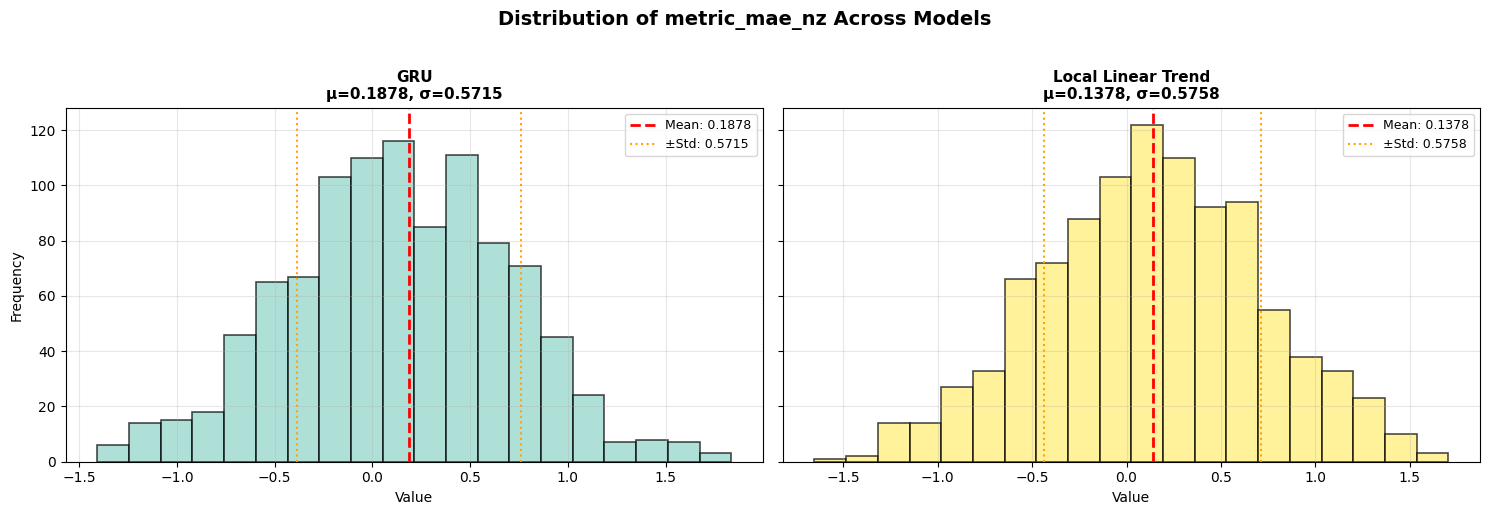

In [15]:
plot_metric_histogram(summary, 'metric_mae_nz')

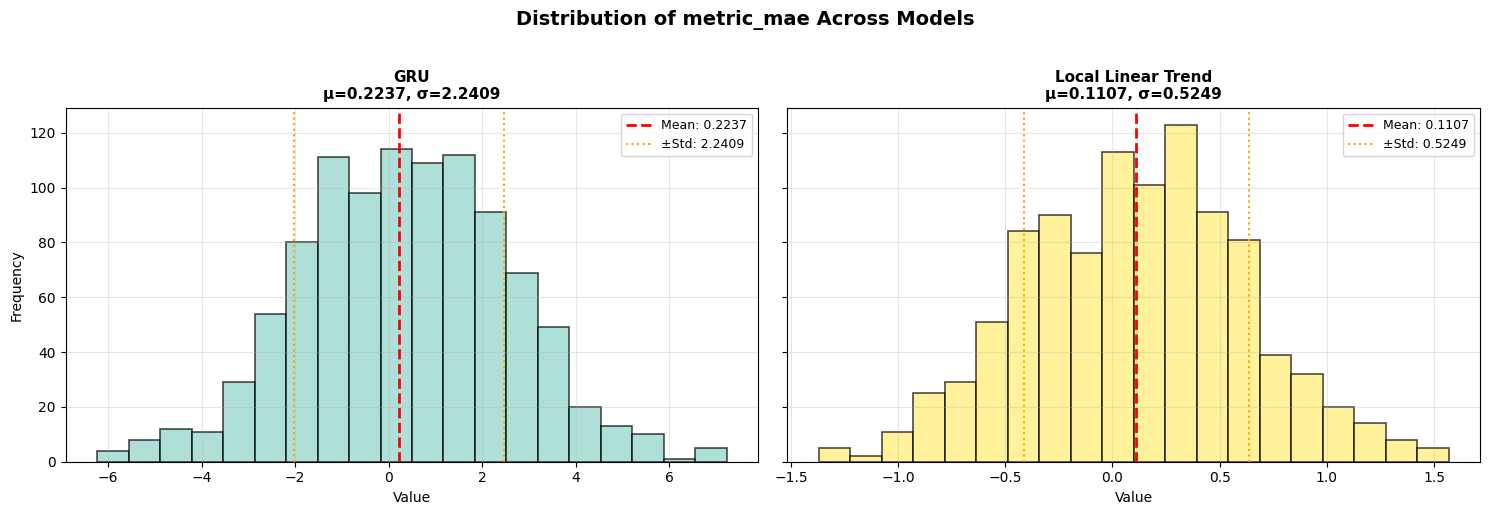

In [16]:
plot_metric_histogram(summary, 'metric_mae')

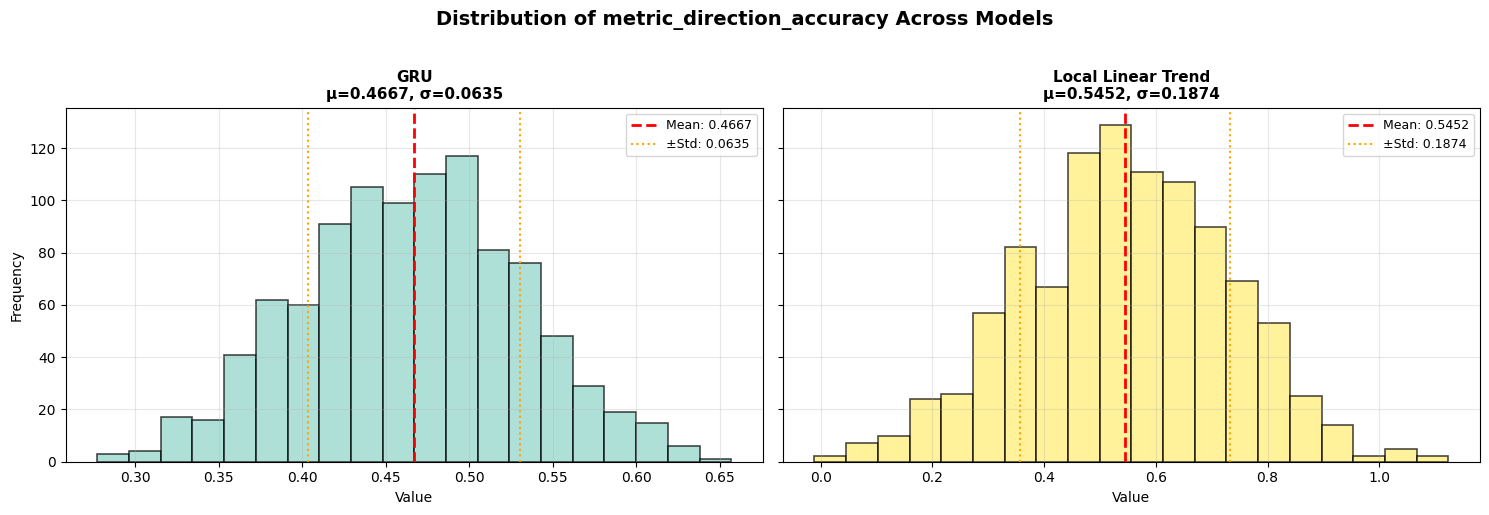

In [17]:
plot_metric_histogram(summary, 'metric_direction_accuracy')